**ANN for Fake Social Media Account Detection**

***Step 1 : Importing Libraries***

In [ ]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder            # Categorial data to Numberical data
from sklearn.metrics import (                                             # model Evaluation using
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_curve,
    roc_auc_score
)

# Deep Learning
import tensorflow as tf                                                 # Workflow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


***Step 2 : Importing the Dataset***

Saving fake_social_media.csv to fake_social_media.csv


In [ ]:
df = pd.read_csv("fake_social_media.csv")
df

,platform,has_profile_pic,bio_length,username_randomness,followers,following,follower_following_ratio,account_age_days,posts,posts_per_day,caption_similarity_score,content_similarity_score,follow_unfollow_rate,spam_comments_rate,generic_comment_rate,suspicious_links_in_bio,verified,is_fake
0,Twitter,1,180,1,431,679,0.633824,941,194,0.205945,0.699444,0.243579,456,44,63,1,1,1
1,Instagram,1,214,0,426,729,0.583562,3164,202,0.063823,0.538005,0.122000,98,196,79,0,0,1
2,Twitter,1,87,0,426,721,0.590028,903,225,0.248894,0.858450,0.835424,136,171,139,0,1,1
3,Twitter,0,72,0,385,679,0.566176,3433,175,0.050961,0.176471,0.916446,186,46,72,1,1,1
4,Instagram,0,162,1,392,709,0.552113,1269,207,0.162992,0.265957,0.214862,35,184,138,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,Twitter,0,118,0,399,683,0.583333,4401,216,0.049069,0.622001,0.060215,342,192,80,1,0,1
2996,Instagram,0,237,1,426,703,0.605114,2227,192,0.086176,0.211756,0.356150,276,56,120,1,1,1
2997,Instagram,1,33,1,418,718,0.581363,3737,203,0.054307,0.128955,0.200159,178,123,108,1,0,1
2998,Facebook,1,168,0,406,722,0.561549,932,202,0.216506,0.909608,0.357878,279,152,144,0,1,1


***Step 3 : Exploring the Dataset***

In [ ]:
df.shape               #Record of Number of Rows and Columns

(3000, 18)

In [ ]:
df.columns            #Displays all the feature names

Index(['platform', 'has_profile_pic', 'bio_length', 'username_randomness',
       'followers', 'following', 'follower_following_ratio',
       'account_age_days', 'posts', 'posts_per_day',
       'caption_similarity_score', 'content_similarity_score',
       'follow_unfollow_rate', 'spam_comments_rate', 'generic_comment_rate',
       'suspicious_links_in_bio', 'verified', 'is_fake'],
      dtype='object')

In [ ]:
df.info()            #Displays data types, non-null values and helps in Identifying missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   platform                  3000 non-null   object 
 1   has_profile_pic           3000 non-null   int64  
 2   bio_length                3000 non-null   int64  
 3   username_randomness       3000 non-null   int64  
 4   followers                 3000 non-null   int64  
 5   following                 3000 non-null   int64  
 6   follower_following_ratio  3000 non-null   float64
 7   account_age_days          3000 non-null   int64  
 8   posts                     3000 non-null   int64  
 9   posts_per_day             3000 non-null   float64
 10  caption_similarity_score  3000 non-null   float64
 11  content_similarity_score  3000 non-null   float64
 12  follow_unfollow_rate      3000 non-null   int64  
 13  spam_comments_rate        3000 non-null   int64  
 14  generic_

In [ ]:
df.describe()    #statistical Summary

,has_profile_pic,bio_length,username_randomness,followers,following,follower_following_ratio,account_age_days,posts,posts_per_day,caption_similarity_score,content_similarity_score,follow_unfollow_rate,spam_comments_rate,generic_comment_rate,suspicious_links_in_bio,verified,is_fake
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,0.489333,125.230667,0.506667,399.933667,700.67300,0.570725,2492.011000,200.255333,0.273532,0.500510,0.496666,248.089333,99.402000,74.481333,0.501000,0.497000,0.997667
std,0.499970,71.511133,0.500039,20.044846,25.89729,0.035164,1431.539864,14.270530,1.660029,0.286945,0.286673,145.200118,57.895501,43.279441,0.500082,0.500074,0.048256
min,0.000000,0.000000,0.000000,334.000000,607.00000,0.467377,2.000000,151.000000,0.034274,0.000146,0.000836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,66.000000,0.000000,386.000000,684.00000,0.545842,1255.750000,190.000000,0.053593,0.254581,0.254665,121.000000,49.000000,38.000000,0.000000,0.000000,1.000000
50%,0.000000,125.000000,1.000000,400.000000,701.00000,0.570437,2462.500000,200.000000,0.081719,0.506433,0.492971,248.000000,100.000000,73.000000,1.000000,0.000000,1.000000
75%,1.000000,186.000000,1.000000,413.000000,718.00000,0.594118,3733.250000,209.000000,0.158421,0.747140,0.740453,376.000000,149.000000,112.250000,1.000000,1.000000,1.000000
max,1.000000,249.000000,1.000000,472.000000,789.00000,0.693679,4997.000000,254.000000,73.333333,0.999812,0.999900,499.000000,199.000000,149.000000,1.000000,1.000000,1.000000


"Understand the numerical features in my dataset before training the ANN model. It provides statistics such as count, mean, standard deviation, minimum, maximum, and quartile values. This helps identify unusual values, understand the distribution of the data, and determine whether preprocessing steps such as feature scaling are required."

In [ ]:
df.isnull().sum()        # Checking missing values

,0
platform,0
has_profile_pic,0
bio_length,0
username_randomness,0
followers,0
following,0
follower_following_ratio,0
account_age_days,0
posts,0
posts_per_day,0


In [ ]:
print("Duplicate Records:", df.duplicated().sum())      #Checking duplicate records

Duplicate Records: 0


Viewing the Target variable

In [ ]:
df['is_fake'].value_counts()    #Target Variable

,count
is_fake,
1,2993
0,7


Visualizing the Target Distribution

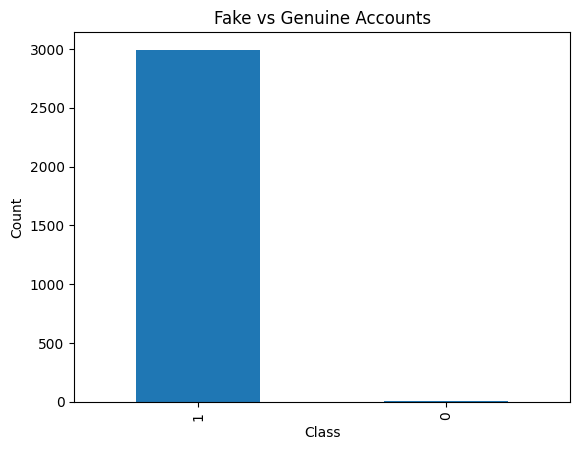

In [ ]:
import matplotlib.pyplot as plt                     #This graph will clearly show whether the dataset is balanced or imbalanced.

df['is_fake'].value_counts().plot(kind='bar')

plt.title("Fake vs Genuine Accounts")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

***Step 4 : Exploratory Data Analysis (EDA)***

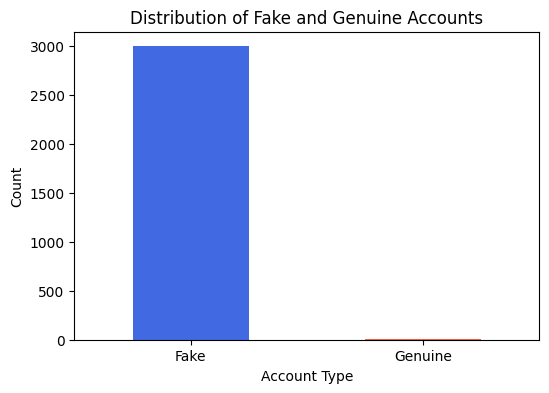

In [ ]:
import matplotlib.pyplot as plt               #plotting the target distribution

plt.figure(figsize=(6,4))

df['is_fake'].value_counts().plot(
    kind='bar',
    color=['royalblue','tomato']
)

plt.title("Distribution of Fake and Genuine Accounts")
plt.xlabel("Account Type")
plt.ylabel("Count")
plt.xticks([0,1],["Fake","Genuine"],rotation=0)

plt.show()

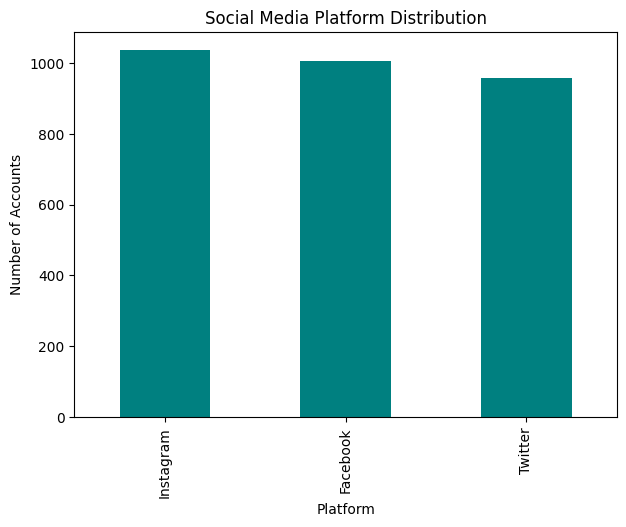

In [ ]:
plt.figure(figsize=(7,5))                  #platform distribution

df['platform'].value_counts().plot(
    kind='bar',
    color='teal'
)

plt.title("Social Media Platform Distribution")
plt.xlabel("Platform")
plt.ylabel("Number of Accounts")

plt.show()

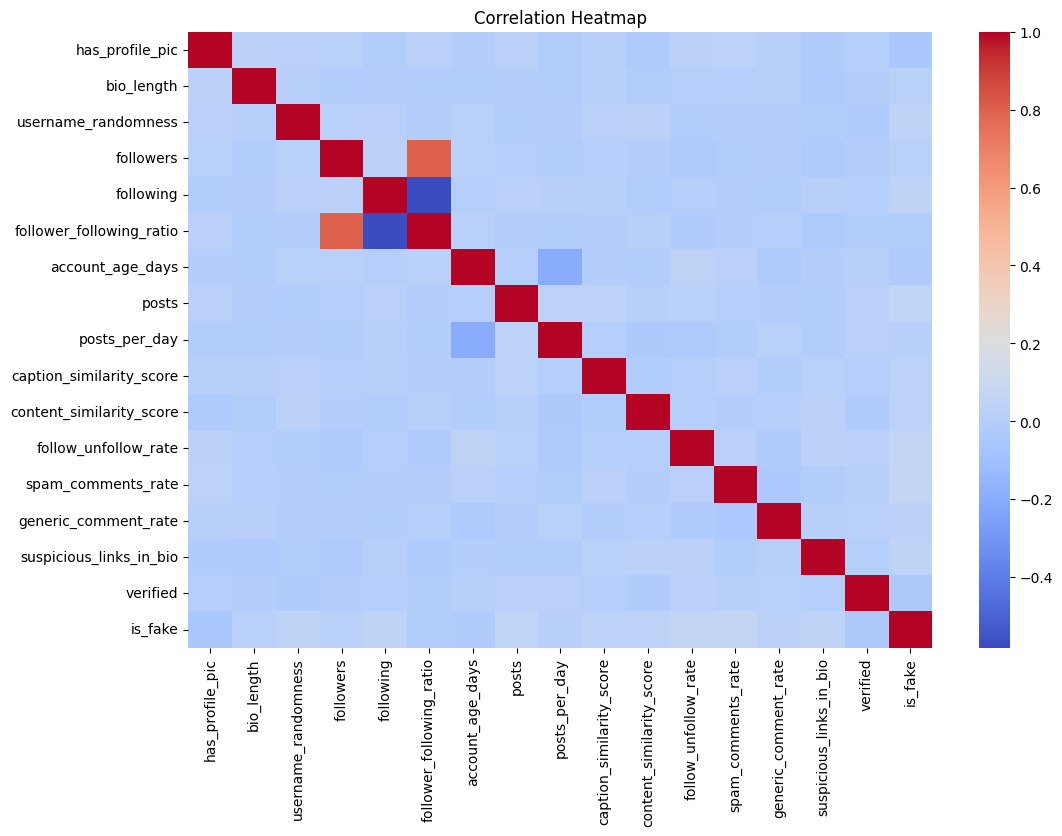

In [ ]:
import seaborn as sns            #Correlation Matrix

plt.figure(figsize=(12,8))

sns.heatmap(
    df.select_dtypes(include=['number']).corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

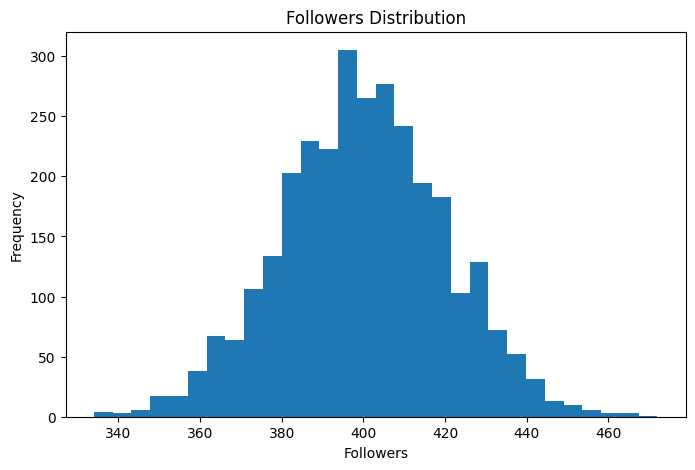

In [ ]:
plt.figure(figsize=(8,5))         #Followers distribution

plt.hist(df['followers'], bins=30)

plt.title("Followers Distribution")
plt.xlabel("Followers")
plt.ylabel("Frequency")

plt.show()

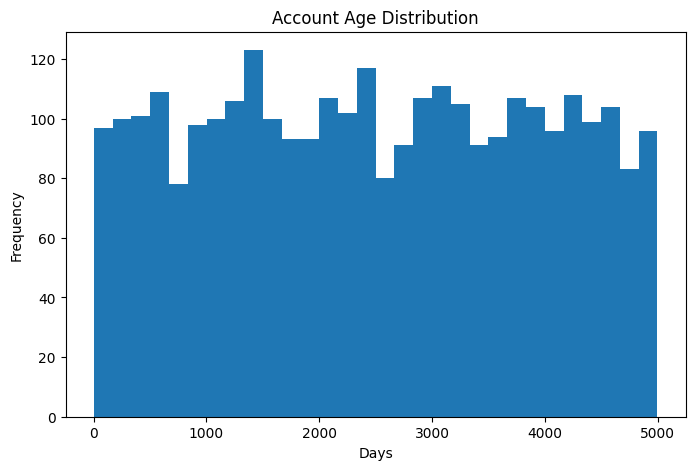

In [ ]:
plt.figure(figsize=(8,5))            #Account Age distribution

plt.hist(df['account_age_days'], bins=30)

plt.title("Account Age Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")

plt.show()

***Step 5: Data Processing***   
* Now we'll prepare the data for the ANN.

In [ ]:
from sklearn.preprocessing import LabelEncoder                 #Encoding the Platform column since platform is the only categorical feature, convert it into numbers.

encoder = LabelEncoder()

df['platform'] = encoder.fit_transform(df['platform'])

df.head()

,platform,has_profile_pic,bio_length,username_randomness,followers,following,follower_following_ratio,account_age_days,posts,posts_per_day,caption_similarity_score,content_similarity_score,follow_unfollow_rate,spam_comments_rate,generic_comment_rate,suspicious_links_in_bio,verified,is_fake
0,2,1,180,1,431,679,0.633824,941,194,0.205945,0.699444,0.243579,456,44,63,1,1,1
1,1,1,214,0,426,729,0.583562,3164,202,0.063823,0.538005,0.122000,98,196,79,0,0,1
2,2,1,87,0,426,721,0.590028,903,225,0.248894,0.858450,0.835424,136,171,139,0,1,1
3,2,0,72,0,385,679,0.566176,3433,175,0.050961,0.176471,0.916446,186,46,72,1,1,1
4,1,0,162,1,392,709,0.552113,1269,207,0.162992,0.265957,0.214862,35,184,138,1,0,1


In [ ]:
X = df.drop('is_fake', axis=1)       #Separating the features and Target

y = df['is_fake']

In [ ]:
print("Features Shape:", X.shape)   #Checking feature and Shape

print("Target Shape:", y.shape)

Features Shape: (3000, 17)
Target Shape: (3000,)


In [ ]:
from sklearn.preprocessing import StandardScaler      #Standardize the features. This scales all numerical features to a similar range, which helps the ANN train more effectively.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

***Step 6 : Handle Class Imbalance using SMOTE***

Install the SMOTE Library

In [ ]:
!pip install imbalanced-learn

In [ ]:
from imblearn.over_sampling import SMOTE


I applied SMOTE before the train-test split to address the severe class imbalance. During review, I learned that the better practice is to split the data first and apply SMOTE only to the training set. This prevents data leakage and provides a more reliable evaluation on unseen test data."

In [ ]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

print("Before SMOTE:")
print(y.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_resampled).value_counts())

Before SMOTE:
is_fake
1    2993
0       7
Name: count, dtype: int64

After SMOTE:
is_fake
1    2993
0    2993
Name: count, dtype: int64


***Step 7 : Split the Dataset***

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.20,
    random_state=42,
    stratify=y_resampled
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (4788, 17)
Testing Data: (1198, 17)


***Step 8 : Building the ANN Model***

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization

model = Sequential()

# Input Layer
model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden Layer 1
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))

# Hidden Layer 3
model.add(Dense(16, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


***Step 9 : Display the Model Summary***

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,953 (54.50 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 384 (1.50 KB)

***Step 10 : Compile the Model***

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

***Step 11 : Early Stopping***

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

***Step 12 : Train the ANN***

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9527 - loss: 0.1485 - val_accuracy: 0.9896 - val_loss: 0.0518
Epoch 2/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9971 - loss: 0.0159 - val_accuracy: 0.9979 - val_loss: 0.0080
Epoch 3/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9990 - loss: 0.0057 - val_accuracy: 0.9990 - val_loss: 0.0030
Epoch 4/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9977 - loss: 0.0076 - val_accuracy: 0.9990 - val_loss: 0.0013
Epoch 5/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9974 - loss: 0.0072 - val_accuracy: 0.9990 - val_loss: 0.0014
Epoch 6/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9977 - loss: 0.0084 - val_accuracy: 1.0000 - val_loss: 3.7302e-04
Epoch 7/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9974 - loss: 0.0074 - val_accuracy: 1.0000 - val_loss: 2.8742e-04
Epoch 8/50
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9992 - loss: 0.0026 - val_accu

***Step 13 : Evaluating the Model***
* Evaluate Accuracy

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss :", loss)
print("Test Accuracy :", accuracy)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 2.2607e-05
Test Loss : 2.2606507627642713e-05
Test Accuracy : 1.0


***Step 14 : Making Predictions***

In [ ]:
y_pred_prob = model.predict(X_test)

y_pred = (y_pred_prob > 0.5).astype(int)

38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


***Step 15 : Classification Report***

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       599
           1       1.00      1.00      1.00       599

    accuracy                           1.00      1198
   macro avg       1.00      1.00      1.00      1198
weighted avg       1.00      1.00      1.00      1198



***Step 16 : Confusion Matrix***

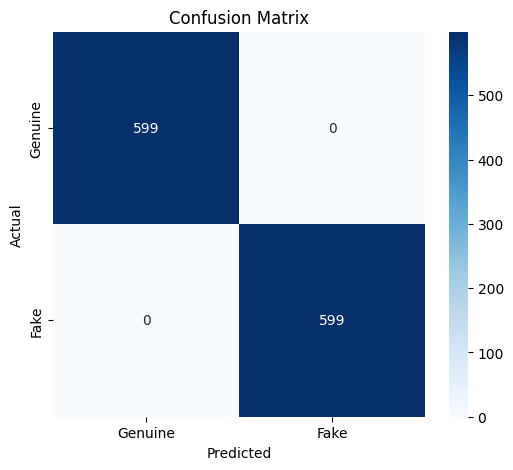

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Genuine','Fake'],
            yticklabels=['Genuine','Fake'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

***Step 17 : ROC Curve***

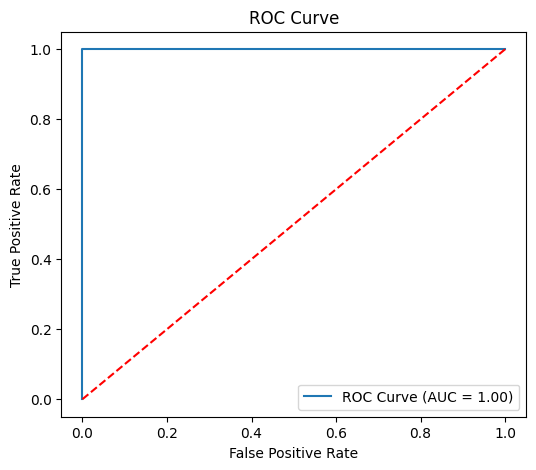

ROC-AUC Score: 1.0


In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='ROC Curve (AUC = %0.2f)' % roc_auc)
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

print("ROC-AUC Score:", roc_auc)

***Step 18 : Plot Training Accuracy***

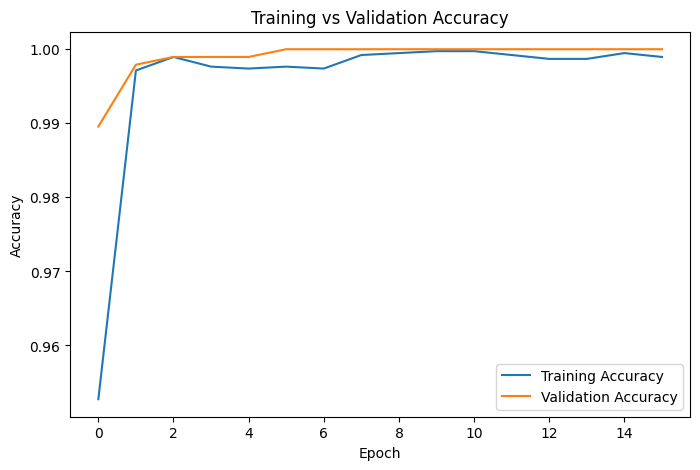

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

***Step 19 : Plot Training Loss***

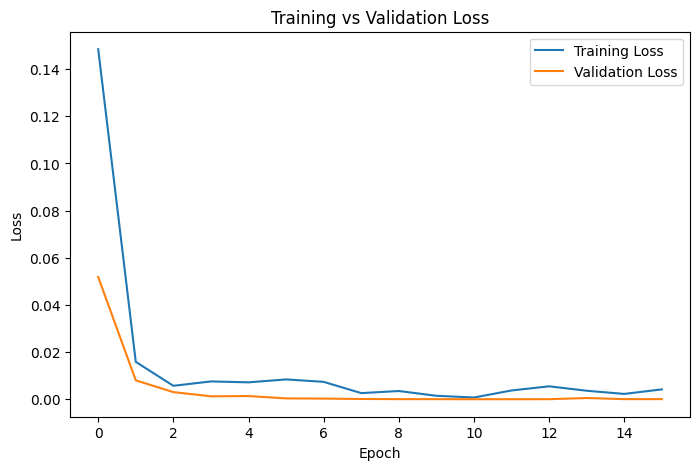

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

***Step 20 : Saving the ANN Model***

In [ ]:
model.save("Fake_Social_Media_ANN.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


***Step 21: Test the Model with a Sample Record***

In [ ]:
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

if prediction > 0.5:
    print("Prediction: Fake Account")
else:
    print("Prediction: Genuine Account")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Prediction: Fake Account


***Project Conclusion***


This project successfully developed an Artificial Neural Network (ANN) model to classify social media accounts as fake or genuine using profile and behavioral features. The workflow included data preprocessing, feature encoding, normalization, handling class imbalance using SMOTE, model training, and evaluation. Performance was assessed using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC. The trained model demonstrates the potential of deep learning for automated fake account detection and can serve as a foundation for future real-time cybersecurity applications.